In [1]:
# SPDX-License-Identifier: CC-BY-4.0
# Code for "Active Continual Learning with Metaplastic Binary Bayesian Neural Networks"
# Kellian Cottart, Théo Ballet, Djohan Bonnet, Damien Querlioz
# Portions of the code are adapted from the Pytorch project (BSD-3-Clause)
# Author: Kellian Cottart <kellian.cottart@gmail.com>
# Date: 2025-30-01

In [2]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
import re
import json
import pandas as pd
import numpy as np
AXESSIZE = 28
FONTSIZE = 26
TICKSIZE = 24   
LEGENDSIZE = 26
plt.rcParams['svg.fonttype'] = 'none'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.05"
results_folder = "results-appendix-openloris-al-switch-time"
figures_folder = "figures-appendix-openloris-al-switch-time"
os.makedirs(figures_folder, exist_ok=True)
df = pd.DataFrame()
# iterate through all root folders in the results folder
for folder in os.listdir(results_folder):
    current_path = os.path.join(results_folder, folder)
    # extract the name from the first config
    config_path = os.path.join(current_path, "config0/config.json")
    with open(config_path, "r") as f:
        config = json.load(f)
    # n_iterations is the number of config folders
    n_iterations = len([f for f in os.listdir(current_path) if f.startswith("config") and os.path.isdir(os.path.join(current_path, f))])
    
    # Add the row of parameters to the dataframe   
    def method_wrapper(config):
        if "active_learning" in config["network_params"]:
            if not "mode" in config["network_params"]["active_learning"]:
                return list(config["network_params"]["active_learning"].keys())[0]  
            else:
                mode_map = {
                    0: "Epistemic",
                    1: "Aleatoric",
                    2: "Predictive",
                    3: "VR",
                    4: "Random",
                    5: "VR-True"
                }
                return mode_map.get(config["network_params"]["active_learning"]["mode"], "Random")
        return "Random"
    
    # Add the row of parameters to the dataframe   
    field = [key for key in config.keys() if "ewc" in key]
    normalisation = config["task_params"].get("dataset_normalisation", "none")
    row = {
        "path": current_path,
        "opt": f"{config['optimizer']}-{normalisation}" if normalisation != "none" else config["optimizer"],
        "n_tasks": config["n_tasks"],
        "n_epochs": config["epochs"],
        "n_train_samples": config["n_train_samples"] if "n_train_samples" in config else 1,
        "n_test_samples": config["n_test_samples"] if "n_test_samples" in config else 1,
        "n_iterations": n_iterations,
        "batch_size": config["train_batch_size"],
        # key containing ewc but not strictly equal to ewc
        "ewc": config[field[0]] if len(field) > 0 else "none",
        "method": method_wrapper(config),
        "n_active_learning_samples": int(config["network_params"]["active_learning"]["samples"]) if "active_learning" in config["network_params"] and "samples" in config["network_params"]["active_learning"] else "none",
        "threshold": float(config["network_params"]["active_learning"]["threshold"]) if "active_learning" in config["network_params"] and "threshold" in config["network_params"]["active_learning"] else "none",
        "N": int(config["optimizer_params"]["N"]) if "N" in config["optimizer_params"] else "none",
        "interleaved": int(config["task_params"].get("interleaved", 0)),
        "n_splits_per_epoch": int(config.get("n_splits_per_epoch", 1)),
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    

In [3]:
df["opt"].unique()

array(['bimu'], dtype=object)

In [4]:
data = []
for idx, row in df.iterrows():
    path = row["path"]
    n_tasks = row["n_tasks"]
    n_epochs = row["n_epochs"]
    n_iterations = row["n_iterations"]
    n_splits_per_epoch = row["n_splits_per_epoch"] if "n_splits_per_epoch" in row else 1
    full_accuracies = []
    full_updates = []
    final_updates = []
    full_wras = []
    full_uras = []
    # indexes_under_represented = np.load(
    # os.path.join(path, "config0", "indexes_under_represented.npy"),
    # allow_pickle=True
    # ).tolist()

    # indexes_well_represented = np.load(
    #     os.path.join(path, "config0", "indexes_well_represented.npy"),
    #     allow_pickle=True
    # ).tolist()
    full_per_class_acc = []
    for it in range(n_iterations):
        current_it_path = os.path.join(path, f"config{it}")
        accuracy_path = os.path.join(current_it_path, "accuracy")
        uncertainty_path = os.path.join(current_it_path, "uncertainty")
        accuracies = []
        updates = []
        wras = []
        uras = []
        class_accuracies = []
        for task in range(n_tasks):
            for epoch in range(n_epochs):
                for split in range(n_splits_per_epoch):
                    suffix = f"split={split}-task={task}-epoch={epoch}.npy"
                    accuracies.append(jnp.load(os.path.join(accuracy_path, suffix)))
                    updates.append(jnp.load(os.path.join(accuracy_path, "iterations-"+suffix)))
                    wras.append(jnp.load(os.path.join(accuracy_path, "wra-"+suffix)))
                    uras.append(jnp.load(os.path.join(accuracy_path, "ura-"+suffix)))
                    #class_accuracies.append(jnp.load(os.path.join(accuracy_path, "per-class-acc-"+suffix)))
        full_accuracies.append(jnp.array(accuracies))
        final_updates.append(jnp.load(os.path.join(current_it_path, "iterations.npy")))
        full_updates.append(jnp.array(updates))
        full_wras.append(jnp.array(wras))
        full_uras.append(jnp.array(uras))
        # full_per_class_acc.append(jnp.array(class_accuracies))

    full_accuracies = jnp.array(full_accuracies)*100
    full_wras = jnp.array(full_wras)*100
    full_uras = jnp.array(full_uras)*100
    full_updates = jnp.array(full_updates)
    final_updates = jnp.array(final_updates).mean()
    # data.append((full_updates, full_accuracies, final_updates, full_wras, full_uras, indexes_under_represented, indexes_well_represented, full_per_class_acc))
    data.append((full_updates, full_accuracies, final_updates, full_wras, full_uras))
    
# Add new columns to df
df["updates"] = [d[0] for d in data]
df["accuracies"] = [d[1] for d in data]
df["final_updates"] = [d[2] for d in data]
df["wras"] = [d[3] for d in data]
df["uras"] = [d[4] for d in data]
# df["indexes_under_represented"] = [d[5] for d in data]
# df["indexes_well_represented"] = [d[6] for d in data]
# df["per_class_acc"] = [d[7] for d in data]


In [104]:
accs = df["accuracies"].item()   # (runs, 1200, 12)
updates = df["updates"].item()   # (runs, 1200)

n_runs, n_steps, n_tasks = accs.shape
task_len = 100

checkpoints = [0, 25, 50, 75, 99]

# your reshape (kept unchanged)
accs_task = accs.reshape(n_runs, task_len, n_tasks, n_tasks)
updates_task = updates.reshape(n_runs, n_tasks, task_len)

rows = []

for t in range(n_tasks):
    row = {"Task": f"Task {t+1}"}

    for cp in checkpoints:
        # DO NOT CHANGE: your original indexing logic
        vals_acc = accs_task[:, cp, t, t]
        # align updates in original stream (correct mapping)
        global_idx = t * task_len + cp
        row[f"Acc@{cp}"] = f"{vals_acc.mean():.2f} ± {vals_acc.std():.2f}"
    for cp in checkpoints:
        vals_upd = updates_task[:, t, cp]  # correct indexing for updates
        row[f"Upd@{cp}"] = f"{vals_upd.mean():.2f} ± {vals_upd.std():.2f}"

    # early / late accuracy dynamics (unchanged structure)
    early = accs_task[:, 24, t, t] - accs_task[:, 0, t, t]
    late = accs_task[:, 99, t, t] - accs_task[:, 74, t, t]

    row["Early acc change"] = f"{early.mean():.2f} ± {early.std():.2f}"
    row["Late acc change"] = f"{late.mean():.2f} ± {late.std():.2f}"

    # early / late updates (consistent with your task segmentation)
    early_upd = updates_task[:, t, 24] - updates_task[:, t, 0]
    late_upd = updates_task[:, t, 99] - updates_task[:, t, 74]

    row["Early updates"] = f"{early_upd.mean():.2f} ± {early_upd.std():.2f}"
    row["Late updates"] = f"{late_upd.mean():.2f} ± {late_upd.std():.2f}"

    rows.append(row)

table = pd.DataFrame(rows)
table

,Task,Acc@0,Acc@25,Acc@50,Acc@75,Acc@99,Upd@0,Upd@25,Upd@50,Upd@75,Upd@99,Early acc change,Late acc change,Early updates,Late updates
0,Task 1,5.26 ± 0.00,86.40 ± 12.42,90.53 ± 6.55,92.54 ± 4.96,90.26 ± 4.30,1.00 ± 0.00,116.80 ± 141.83,189.80 ± 166.66,283.40 ± 156.76,331.60 ± 169.16,82.37 ± 11.76,-2.24 ± 1.25,114.80 ± 140.61,50.60 ± 44.01
1,Task 2,5.26 ± 0.00,92.72 ± 3.96,92.50 ± 4.16,93.03 ± 2.93,91.01 ± 2.79,348.80 ± 177.43,504.00 ± 253.88,574.60 ± 288.27,663.60 ± 214.20,717.80 ± 181.47,88.60 ± 3.93,-1.75 ± 1.78,152.60 ± 76.45,57.40 ± 33.64
2,Task 3,8.73 ± 6.93,94.21 ± 1.19,89.82 ± 0.58,89.47 ± 1.68,88.11 ± 1.78,737.00 ± 182.20,932.40 ± 174.18,1007.40 ± 177.54,1054.80 ± 175.04,1093.00 ± 177.63,86.23 ± 7.57,-1.32 ± 2.00,191.00 ± 9.72,39.00 ± 4.05
3,Task 4,8.90 ± 7.28,75.53 ± 3.06,94.61 ± 2.59,95.96 ± 1.19,91.93 ± 1.32,1110.40 ± 171.86,1273.60 ± 170.05,1325.80 ± 173.99,1356.80 ± 172.83,1383.20 ± 171.81,56.97 ± 7.24,-3.46 ± 1.26,160.60 ± 6.41,26.80 ± 3.37
4,Task 5,12.68 ± 9.56,55.18 ± 2.04,95.44 ± 0.93,94.65 ± 0.97,90.00 ± 1.28,1406.20 ± 169.26,1577.80 ± 173.52,1629.20 ± 173.89,1659.00 ± 178.51,1678.60 ± 181.06,43.55 ± 9.58,-5.04 ± 1.54,167.60 ± 6.71,21.00 ± 3.74
5,Task 6,11.45 ± 10.22,37.85 ± 3.13,93.51 ± 1.74,91.54 ± 2.68,81.14 ± 1.21,1697.20 ± 183.42,1889.00 ± 179.87,1956.40 ± 184.20,2001.00 ± 189.33,2027.40 ± 191.43,24.96 ± 8.95,-11.71 ± 0.89,187.40 ± 9.39,27.40 ± 3.88
6,Task 7,18.60 ± 17.69,66.10 ± 4.36,80.88 ± 3.11,91.89 ± 0.31,90.31 ± 0.78,2040.00 ± 190.61,2201.00 ± 193.93,2282.60 ± 185.67,2354.60 ± 183.89,2406.80 ± 182.50,43.68 ± 15.02,-1.58 ± 0.76,155.80 ± 14.59,55.00 ± 4.56
7,Task 8,18.25 ± 16.71,68.33 ± 2.48,80.44 ± 2.69,96.45 ± 0.95,93.60 ± 0.97,2413.40 ± 182.85,2539.00 ± 182.75,2614.00 ± 181.94,2667.00 ± 181.22,2708.60 ± 180.94,46.89 ± 15.01,-2.46 ± 0.76,122.40 ± 13.34,43.20 ± 4.26
8,Task 9,12.32 ± 8.70,39.61 ± 2.42,53.25 ± 2.05,91.54 ± 1.36,80.96 ± 1.06,2725.80 ± 181.18,2952.20 ± 187.74,3076.40 ± 182.66,3166.60 ± 186.39,3239.20 ± 180.15,23.25 ± 9.07,-10.22 ± 2.00,220.40 ± 16.41,75.80 ± 11.25
9,Task 10,19.78 ± 17.86,68.82 ± 3.38,70.79 ± 2.00,83.25 ± 1.57,89.78 ± 1.40,3247.80 ± 180.20,3366.20 ± 177.77,3439.20 ± 176.87,3494.40 ± 177.86,3531.20 ± 184.93,42.24 ± 17.42,12.15 ± 1.73,115.60 ± 4.36,39.00 ± 7.62


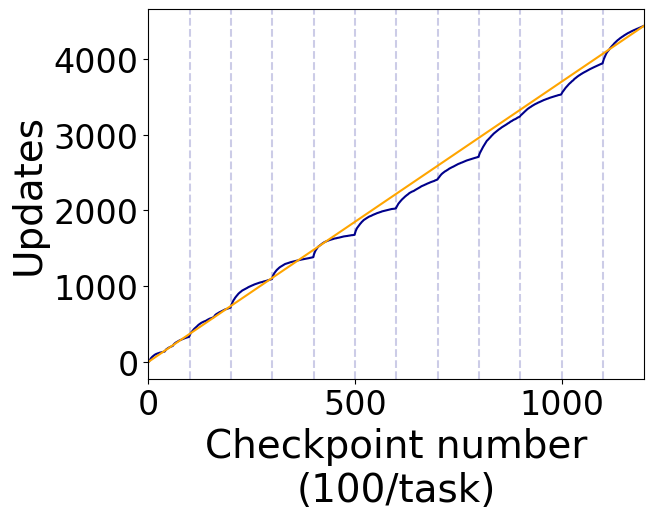

In [35]:
mean_updates_over_runs = updates.mean(axis=0)  # (1200,)

plt.figure()
plt.plot(mean_updates_over_runs, color="darkblue")
for task in range(1, n_tasks):
    plt.axvline(task * task_len, linestyle="--", color="darkblue", alpha=0.2)
# plot linear behaviour for reference
plt.plot(np.arange(n_tasks * task_len), np.linspace(mean_updates_over_runs[0], mean_updates_over_runs[-1], n_tasks * task_len), linestyle="-", color="orange")

plt.xlabel("Checkpoint number\n(100/task)", fontsize=AXESSIZE)
plt.ylabel("Updates", fontsize=AXESSIZE)
plt.xlim(0, n_tasks * task_len)
plt.tick_params(axis='both', which='major', labelsize=TICKSIZE)
plt.show()

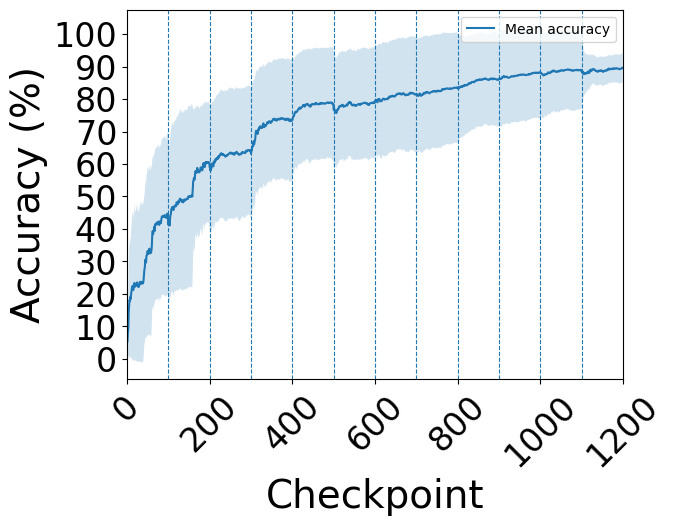

In [62]:
accs = df["accuracies"].item()  # (5, 1200, 12)

# average over runs and tasks -> (1200,)
mean_acc = accs.mean(axis=(0, 2))
std_acc = accs.std(axis=(0, 2))

epochs = np.arange(mean_acc.shape[0])

plt.figure()
plt.plot(epochs, mean_acc, label="Mean accuracy")
plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2
)

# task boundaries
task_len = 100
for t in range(1, 12):
    plt.axvline(t * task_len, linestyle="--", linewidth=0.8)

plt.xlabel("Checkpoint", fontsize=AXESSIZE)
plt.ylabel("Accuracy (%)", fontsize=AXESSIZE)
plt.tick_params(axis='both', which='major', labelsize=TICKSIZE)
plt.xticks(np.arange(0, n_tasks * task_len + 1, task_len*2), rotation=45)
plt.yticks(np.arange(0, 101, 10))
plt.xlim(0, n_tasks * task_len)
plt.legend()
plt.show()

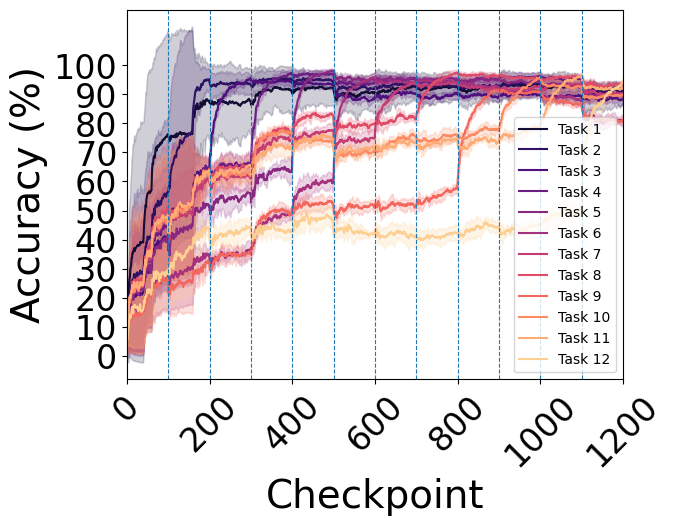

In [64]:
accs = df["accuracies"].item()  # (5, 1200, 12)

n_runs, n_steps, n_tasks = accs.shape
task_len = 100

epochs = np.arange(n_steps)

# average over runs -> (1200, 12)
mean_acc = accs.mean(axis=0)
std_acc = accs.std(axis=0)

cmap = plt.cm.magma
colors = cmap(np.linspace(0.1, 0.9, n_tasks))

plt.figure()

for t in range(n_tasks):
    plt.plot(
        epochs,
        mean_acc[:, t],
        color=colors[t],
        label=f"Task {t+1}"
    )
    plt.fill_between(
        epochs,
        mean_acc[:, t] - std_acc[:, t],
        mean_acc[:, t] + std_acc[:, t],
        color=colors[t],
        alpha=0.2
    )

# task boundaries
for t in range(1, n_tasks):
    plt.axvline(t * task_len, linestyle="--", linewidth=0.8)

plt.xlabel("Checkpoint", fontsize=AXESSIZE)
plt.ylabel("Accuracy (%)", fontsize=AXESSIZE)
plt.tick_params(axis='both', which='major', labelsize=TICKSIZE)

plt.xticks(np.arange(0, n_tasks * task_len + 1, task_len * 2), rotation=45)
plt.yticks(np.arange(0, 101, 10))

plt.xlim(0, n_tasks * task_len)
plt.legend()
plt.show()